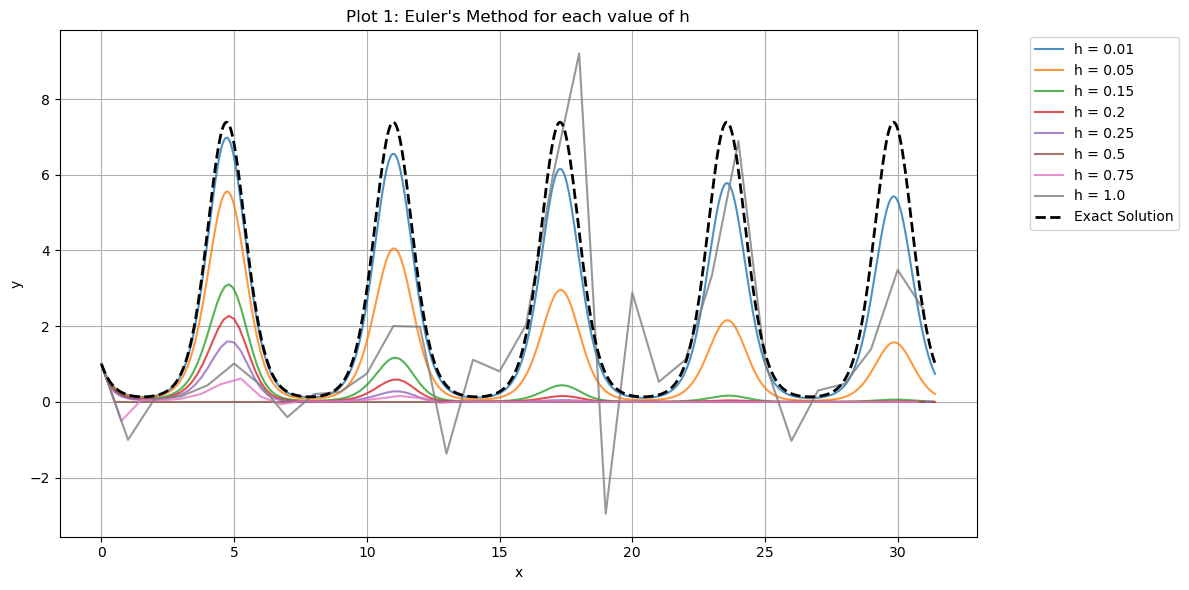

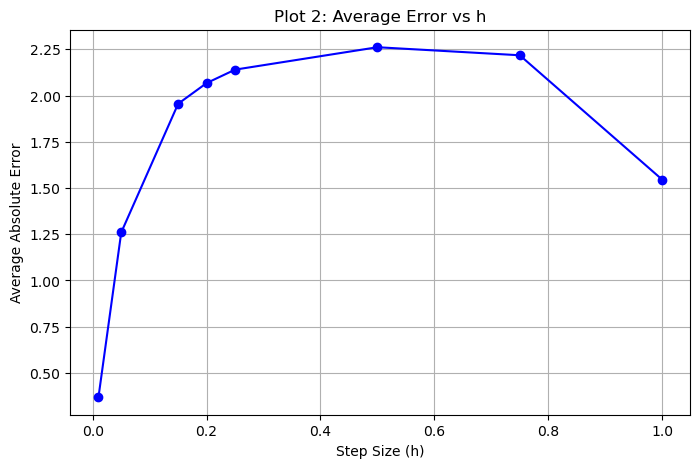

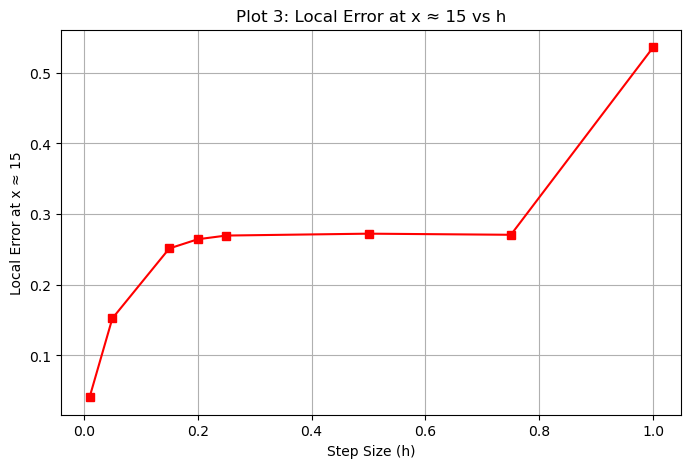

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x_start = 0
x_end = 10 * np.pi
y_start = 1

h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 0.5, 0.75, 1.0]

def f(x, y):
    return -2 * y * np.cos(x)

def exact_solution(x):
    return np.exp(-2 * np.sin(x))

avg_errors = []
local_errors_15 = []
plt.figure(figsize=(12, 6))

for h in h_values:
    num_steps = int(np.ceil((x_end - x_start) / h))
    x_values = np.linspace(x_start, x_start + num_steps * h, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = y_start
    
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
    valid_indices = x_values <= x_end
    x_values = x_values[valid_indices]
    y_values = y_values[valid_indices]
    y_true = exact_solution(x_values)
    
    plt.plot(x_values, y_values, label=f'h = {h}', alpha=0.8)
    avg_error = np.mean(np.abs(y_values - y_true))
    avg_errors.append(avg_error)
    idx_15 = np.argmin(np.abs(x_values - 15))
    local_error = np.abs(y_values[idx_15] - y_true[idx_15])
    local_errors_15.append(local_error)

x_fine = np.linspace(x_start, x_end, 1000)
plt.plot(x_fine, exact_solution(x_fine), 'k--', linewidth=2, label='Exact Solution')

plt.xlabel('x')
plt.ylabel('y')
plt.title("Plot 1: Euler's Method for each value of h")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(h_values, avg_errors, marker='o', linestyle='-', color='b')
plt.xlabel('Step Size (h)')
plt.ylabel('Average Absolute Error')
plt.title('Plot 2: Average Error vs h')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(h_values, local_errors_15, marker='s', linestyle='-', color='r')
plt.xlabel('Step Size (h)')
plt.ylabel('Local Error at x ≈ 15')
plt.title('Plot 3: Local Error at x ≈ 15 vs h')
plt.grid(True)
plt.show()

## Write up: This code shows the accuracy and stability of Euler's method. The first plot shows different h values within Euler's method versus the exact solution. The second shows the average error based on these h values or step sizes. Then the third shows local error based on the step size or h values. 

In [2]:
## HW 7 Addendum
import numpy as np
h_test_values = [0.1, 0.5, 0.9, 1.0, 1.1, 1.5]
x_values = np.linspace(0, 2 * np.pi, 1000)

print("--- Local Stability Analysis for dy/dx = -2y*cos(x) ---")
print("Euler's method is stable if the Amplification Factor |1 - 2h*cos(x)| <= 1 everywhere.\n")

for h in h_test_values:
    amp_factors = np.abs(1 - 2 * h * np.cos(x_values))
    max_amp = np.max(amp_factors)
    is_stable = max_amp <= 1.0 + 1e-10 
    
    status = "STABLE" if is_stable else "UNSTABLE"
    print(f"h = {h:<4.1f} | Max Amplification Factor: {max_amp:<6.4f} | Status: {status}")

--- Local Stability Analysis for dy/dx = -2y*cos(x) ---
Euler's method is stable if the Amplification Factor |1 - 2h*cos(x)| <= 1 everywhere.

h = 0.1  | Max Amplification Factor: 1.2000 | Status: UNSTABLE
h = 0.5  | Max Amplification Factor: 2.0000 | Status: UNSTABLE
h = 0.9  | Max Amplification Factor: 2.8000 | Status: UNSTABLE
h = 1.0  | Max Amplification Factor: 3.0000 | Status: UNSTABLE
h = 1.1  | Max Amplification Factor: 3.2000 | Status: UNSTABLE
h = 1.5  | Max Amplification Factor: 4.0000 | Status: UNSTABLE
